In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Preprocessing

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#ALL lap data f1 2019-2025
laps = pd.read_csv(r'/content/drive/MyDrive/ML/f1_pace_deg.csv')

#PREPROCESSING
def preprocess(laps, race, compound):
  #get all laps from race on compound
  if race == 'ALL' and compound == 'ALL':
    df = laps
  elif compound == 'ALL':
    df = laps[(laps['Race'] == race)]
  elif race == 'ALL':
    df = laps[(laps['Compound'] == compound)]
  else:
    df = laps[(laps['Race'] == race) & (laps['Compound'] == compound)]
  #remove noisy rows
  df = df[(df['StintLengthOutlierFlag_x'] == 0) & (df['RainFlag'] == 0) &
            (df['NoisyLapFlag'] == 0) & (df['WarmupLapFlag'] == 0) & (df['NoisyDeltaFlag'] == 0)]
  #still some noise... delete all laps where lap time is more than 107% of the session average (GROUP BY RACE AND YEAR FIRST)
  df['LapDelta'] = df['LapDelta'].clip(-1.5, 1.5)
  #remove null values
  df = df.dropna()
  #create driver-normalized lap time
  df['LapTime_DriverNormalized'] = df['LapTime_Raw'] - df.groupby(['Race','Driver', 'Year'])['LapTime_Raw'].transform('mean')
  #get features & metadata
  df = df[['Race', 'Driver', 'Compound', 'Year', 'LapNumber', 'StintLap', 'LapTime_Raw', 'LapTime_DriverNormalized', 'LapDelta']]
  #change all Race column values of "Mexican Grand Prix" to "Mexico City Grand Prix"
  laps['Race'] = laps['Race'].replace('Mexican Grand Prix', 'Mexico City Grand Prix')
  return df


#specify races and compounds to analyze
races = ['Abu Dhabi Grand Prix', 'Bahrain Grand Prix', 'Mexico City Grand Prix']
compounds = ['SOFT', 'MEDIUM', 'HARD']
#races = ['ALL']
#compounds = ['ALL']

# Predict Lap Time Deltas (change between current lap and next lap) using linear regression

In [11]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

#ridge model
def linreg(race, compound):
  #preprocess data
  df = preprocess(laps, race, compound)
  #get features
  X = df[['StintLap']] # Changed to df[['StintLap']] to make it 2D
  y = df['LapDelta']
  #train test split/standard scale
  X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=1)
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)
  #ridge regression
  lr = LinearRegression()
  lr.fit(X_train, Y_train)
  coefficient = lr.coef_
  intercept = lr.intercept_
  #get true coefficients and bias for non-normailzed data
  true_coef = coefficient / scaler.scale_ # Uncommented and adapted for single feature
  true_bias = intercept - np.sum((true_coef * scaler.mean_)) # Uncommented and adapted for single feature
  #test
  Y_pred = lr.predict(X_test)
  rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
  mae = mean_absolute_error(Y_test, Y_pred)
  #print coefficients and test results
  print(f'Linear Regression model for {compound} tyres at {race}:')
  print(f'Lap Delta = ({true_coef[0]} x Stint Lap) + {true_bias}') # Changed to use true_coef and true_bias
  print(f'RMSE: {rmse}')
  print(f'MAE: {mae}\n')
  return true_coef, true_bias, rmse, mae

#create table for coefficients and bias
coefficients = pd.DataFrame(columns=['Race', 'Compound', 'Tire_Coef', 'Baseline_Pace'])
RMSEs = []
MAEs = []
for race in races:
  for compound in compounds:
    coef, bias, rmse, mae = linreg(race, compound)
    # Populating Fuel_Coef with np.nan as it's not used in this model
    coefficients.loc[len(coefficients)] = [race, compound, coef[0], bias]
    RMSEs.append(rmse)
    MAEs.append(mae)

#for later analysis
MAEs_PaceDeg = MAEs

#display average MAE across all track/compound combinations
print(f'Average MAE across all track/compound combinations: {np.mean(MAEs_PaceDeg)}')

Linear Regression model for SOFT tyres at Abu Dhabi Grand Prix:
Lap Delta = (0.011309949229656337 x Stint Lap) + -0.06385674447847149
RMSE: 0.5000964741066737
MAE: 0.353450240608051

Linear Regression model for MEDIUM tyres at Abu Dhabi Grand Prix:
Lap Delta = (0.007362428158374616 x Stint Lap) + -0.08880946941738953
RMSE: 0.5156524206491395
MAE: 0.36304940554670945

Linear Regression model for HARD tyres at Abu Dhabi Grand Prix:
Lap Delta = (0.00018371913298250984 x Stint Lap) + -0.02602434892512925
RMSE: 0.43779788953778737
MAE: 0.3033978351272554

Linear Regression model for SOFT tyres at Bahrain Grand Prix:
Lap Delta = (-0.0008918385612302197 x Stint Lap) + 0.09225765509270717
RMSE: 0.48009062569772637
MAE: 0.3362239715266793

Linear Regression model for MEDIUM tyres at Bahrain Grand Prix:
Lap Delta = (-0.003356874244049372 x Stint Lap) + 0.09763676526856996
RMSE: 0.517281004666975
MAE: 0.373811759891037

Linear Regression model for HARD tyres at Bahrain Grand Prix:
Lap Delta = (-0

# Visualize how Pace Deg model projects lap time progression over a tire stint

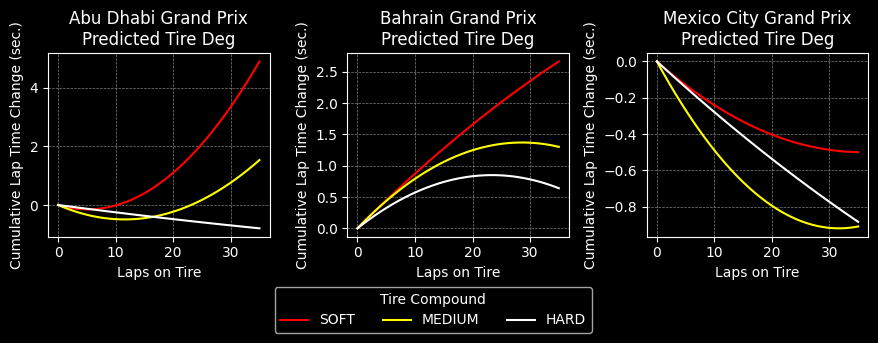

In [13]:


#plot predicted lap time progression over time for each track/compound
# color map
compound_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white'}

fig, axes = plt.subplots(1, len(races), figsize=(9, 3))

for i, race in enumerate(races):
    ax = axes[i]
    race_df = coefficients[coefficients['Race'] == race]
    legend_labels = []
    x_laps = np.arange(1, 36)  # stint length (adjust if needed)

    for compound in compounds:
        compound_df = race_df[race_df['Compound'] == compound]
        coef = compound_df['Tire_Coef'].values[0]
        bias = compound_df['Baseline_Pace'].values[0]
        #predicted lap deltas
        y_delta = coef * x_laps + bias
        #cumulative lap time change (THIS is the key step)
        y_cumulative = np.cumsum(y_delta)
        #start at 0 for lap 0
        y_cumulative = np.insert(y_cumulative, 0, 0)
        x_plot = np.insert(x_laps, 0, 0)
        #plot
        ax.plot(x_plot, y_cumulative,
                color=compound_colors[compound],
                label=compound)
        #legend label
        legend_labels.append(compound)

    ax.set_xlabel('Laps on Tire')
    ax.set_ylabel('Cumulative Lap Time Change (sec.)')
    ax.set_title(f'{race}\nPredicted Tire Deg', color='white')
    ax.grid(color='gray', linestyle='--', linewidth=0.5)

# shared legend (same style as your original)
fig.legend(legend_labels,
           loc='lower center',
           ncol=3,
           bbox_to_anchor=(0.5, -0.15),
           facecolor='black',
           labelcolor='white',
           title='Tire Compound')
plt.tight_layout()
plt.show()

# Export Coefficients to CSV

In [ ]:
coefficients.to_csv(r'/content/drive/MyDrive/ML/pacedeg_coefficients.csv')